In [1]:
import os
import kagglehub

source_path = kagglehub.dataset_download(
    "nikhilpandey360/chest-xray-masks-and-labels"
)

print("Dataset path:")
print(source_path)

print("\n========== DATASET CONTENTS ==========")

for root, dirs, files in os.walk(source_path):
    pngs = [f for f in files if f.lower().endswith(".png")]

    if pngs:
        print("\nFolder:", root)
        print("PNG files:", len(pngs))
        print("Examples:", pngs[:5])

Dataset path:
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels

========== DATASET CONTENTS ==========

Folder: /kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/CXR_png
PNG files: 800
Examples: ['CHNCXR_0092_0.png', 'CHNCXR_0322_0.png', 'CHNCXR_0304_0.png', 'CHNCXR_0572_1.png', 'CHNCXR_0547_1.png']

Folder: /kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/masks
PNG files: 704
Examples: ['CHNCXR_0300_0_mask.png', 'CHNCXR_0083_0_mask.png', 'CHNCXR_0094_0_mask.png', 'CHNCXR_0597_1_mask.png', 'MCUCXR_0017_0.png']

Folder: /kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/test
PNG files: 96
Examples: ['CHNCXR_0349_1.png', 'CHNCXR_0036_0.png', 'CHNCXR_0481_1.png', 'CHNCXR_0184_0.png', 'CHNCXR_0497_1.png']

Folder: /kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/CXR_png
PNG files: 800
Examples: ['CHNCXR_0092_0.png', 'C

In [2]:
import os
import re
import glob
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# 1. Target the exact CXR_png folder
cxr_folder = "/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/CXR_png"
if not os.path.exists(cxr_folder):
    cxr_folder = "/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/CXR_png"

print(f"Reading CXR images from: {cxr_folder}")

# Regex to validate official NLM filename labels
SHENZHEN_REGEX = re.compile(r"^CHNCXR_\d+_(0|1)\.png$")
MONTGOMERY_REGEX = re.compile(r"^MCUCXR_\d+_(0|1)\.png$")

records = []
for filename in os.listdir(cxr_folder):
    file_path = os.path.join(cxr_folder, filename)
    
    # Shenzhen parser
    match_sz = SHENZHEN_REGEX.match(filename)
    if match_sz:
        records.append({
            "image_id": filename,
            "file_path": file_path,
            "source_dataset": "Shenzhen",
            "label": int(match_sz.group(1))
        })
        continue

    # Montgomery parser
    match_mc = MONTGOMERY_REGEX.match(filename)
    if match_mc:
        records.append({
            "image_id": filename,
            "file_path": file_path,
            "source_dataset": "Montgomery",
            "label": int(match_mc.group(1))
        })

df = pd.DataFrame(records).sort_values(by="image_id").reset_index(drop=True)

# 2. Benchmark Verification
expected_counts = {
    ("Shenzhen", 0): 326,
    ("Shenzhen", 1): 336,
    ("Montgomery", 0): 80,
    ("Montgomery", 1): 58
}

print("\n================ DATASET AUDIT ================")
print(f"Total Unique CXRs Found: {len(df)}")
print(pd.crosstab(df["source_dataset"], df["label"], margins=True, 
                  rownames=["Cohort"], colnames=["Class (0=Normal, 1=TB-Consistent)"]))

print("\n================ BENCHMARK COUNT CHECK ================")
all_passed = True
for (dataset, label), expected in expected_counts.items():
    actual = len(df[(df["source_dataset"] == dataset) & (df["label"] == label)])
    status = "OK" if actual == expected else "MISMATCH"
    if actual != expected:
        all_passed = False
    print(f"{dataset:12s} | Label {label} | Expected: {expected:3d} | Found: {actual:3d} | [{status}]")

if len(df) == 800 and all_passed:
    print("\nâœ… DATASET VERIFICATION PASSED (800 / 800 images)")
else:
    print("\nâš ï¸ DATASET VERIFICATION FAILED.")
    raise SystemExit("Dataset audit failed.")

# 3. Stratified 5-Fold Partition
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(df, df["label"])):
    df.loc[val_idx, "fold"] = fold_idx

print("\n================ FOLD DISTRIBUTION ================")
print(pd.crosstab(df["fold"], df["label"], margins=True, 
                  rownames=["Fold"], colnames=["Class (0=Normal, 1=TB-Consistent)"]))

# 4. Save metadata
output_path = "/kaggle/working/tb_metadata.csv"
df.to_csv(output_path, index=False)
print(f"\nMetadata CSV successfully saved to: {output_path}")

Reading CXR images from: /kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/CXR_png

================ DATASET AUDIT ================
Total Unique CXRs Found: 800
Class (0=Normal, 1=TB-Consistent)    0    1  All
Cohort                                          
Montgomery                          80   58  138
Shenzhen                           326  336  662
All                                406  394  800

================ BENCHMARK COUNT CHECK ================
Shenzhen     | Label 0 | Expected: 326 | Found: 326 | [OK]
Shenzhen     | Label 1 | Expected: 336 | Found: 336 | [OK]
Montgomery   | Label 0 | Expected:  80 | Found:  80 | [OK]
Montgomery   | Label 1 | Expected:  58 | Found:  58 | [OK]

âœ… DATASET VERIFICATION PASSED (800 / 800 images)

================ FOLD DISTRIBUTION ================
Class (0=Normal, 1=TB-Consistent)    0    1  All
Fold                                            
0                                   82   78  160
1             

In [3]:
!pip install -q ptflops

Device: cuda (Tesla T4)

            BENCHMARKING: RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 97.8M/97.8M [00:00<00:00, 174MB/s]


Complexity: 23.51M Params | 8.26 GFLOPs | 6.16 ms/img
Fold 1/5 (Stopped ep 20) | OOF AUC: 0.9540 | Sens: 0.7949 | Spec: 0.9146 | F1: 0.8435
Fold 2/5 (Stopped ep 24) | OOF AUC: 0.9512 | Sens: 0.8861 | Spec: 0.9383 | F1: 0.9091
Fold 3/5 (Stopped ep 20) | OOF AUC: 0.9644 | Sens: 0.8987 | Spec: 0.9136 | F1: 0.9045
Fold 4/5 (Stopped ep 23) | OOF AUC: 0.9539 | Sens: 0.7342 | Spec: 1.0000 | F1: 0.8467
Fold 5/5 (Stopped ep 16) | OOF AUC: 0.9580 | Sens: 0.6329 | Spec: 0.9877 | F1: 0.7692

            BENCHMARKING: DENSENET121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 30.8M/30.8M [00:00<00:00, 178MB/s]


Complexity: 6.96M Params | 5.80 GFLOPs | 15.21 ms/img
Fold 1/5 (Stopped ep 19) | OOF AUC: 0.9611 | Sens: 0.8077 | Spec: 0.9512 | F1: 0.8690
Fold 2/5 (Stopped ep 14) | OOF AUC: 0.9497 | Sens: 0.8354 | Spec: 0.9630 | F1: 0.8919
Fold 3/5 (Stopped ep 23) | OOF AUC: 0.9687 | Sens: 0.8734 | Spec: 0.9383 | F1: 0.9020
Fold 4/5 (Stopped ep 15) | OOF AUC: 0.9475 | Sens: 0.8228 | Spec: 0.9136 | F1: 0.8609
Fold 5/5 (Stopped ep 17) | OOF AUC: 0.9662 | Sens: 0.9241 | Spec: 0.8642 | F1: 0.8957

            BENCHMARKING: EFFICIENTNET_B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 20.5M/20.5M [00:00<00:00, 173MB/s]


Complexity: 4.01M Params | 0.82 GFLOPs | 7.88 ms/img
Fold 1/5 (Stopped ep 24) | OOF AUC: 0.9556 | Sens: 0.8462 | Spec: 0.9268 | F1: 0.8800
Fold 2/5 (Stopped ep 17) | OOF AUC: 0.9498 | Sens: 0.8734 | Spec: 0.9012 | F1: 0.8846
Fold 3/5 (Stopped ep 27) | OOF AUC: 0.9587 | Sens: 0.8608 | Spec: 0.9136 | F1: 0.8831
Fold 4/5 (Stopped ep 24) | OOF AUC: 0.9603 | Sens: 0.8861 | Spec: 0.8889 | F1: 0.8861
Fold 5/5 (Stopped ep 18) | OOF AUC: 0.9655 | Sens: 0.9114 | Spec: 0.9630 | F1: 0.9351

             TABLE 1: COMPREHENSIVE PAPER 1 BENCHMARK SUMMARY
   Architecture  Params (M)  GFLOPs  Disk (MB)  Latency (ms)  OOF ROC-AUC (Global) ROC-AUC (Mean Â± SD) Sensitivity (Mean Â± SD) Specificity (Mean Â± SD) F1-Score (Mean Â± SD)
    densenet121        6.96    5.80       27.1         15.21                0.9566     0.9586 Â± 0.0086         0.8527 Â± 0.0418         0.9260 Â± 0.0350      0.8839 Â± 0.0160
efficientnet_b0        4.01    0.82       15.6          7.88                0.9559     0.9580 Â± 0.005

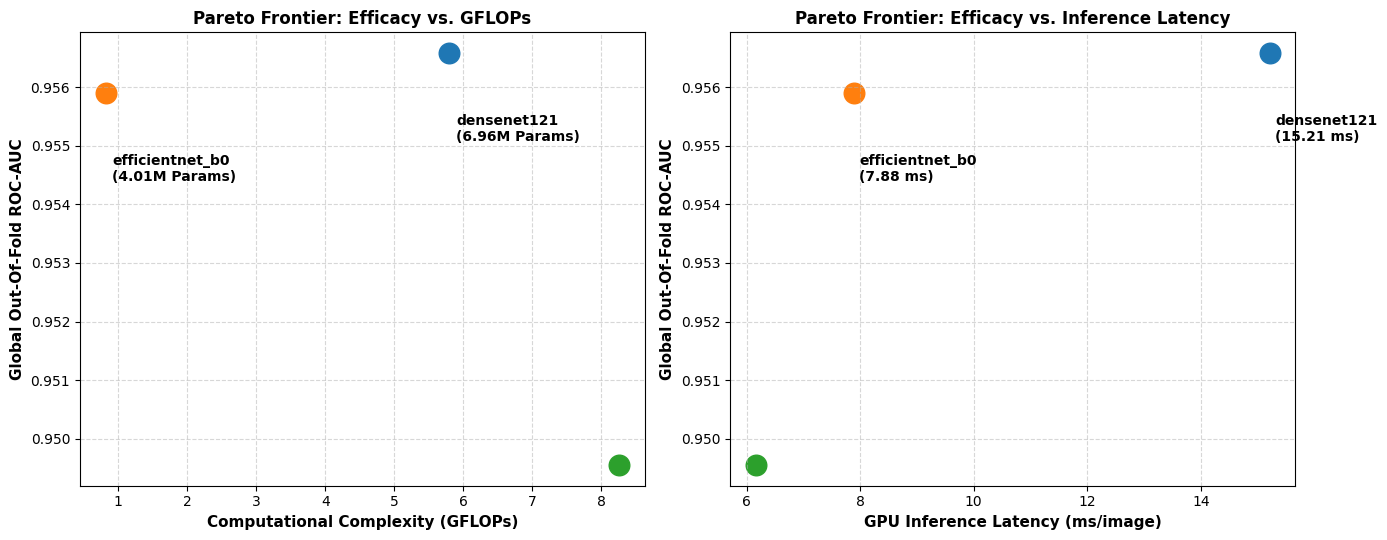


Pareto plot saved to: /kaggle/working/pareto_frontier_paper1.png


In [4]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score, accuracy_score
)
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info

# ============================================================
# 1. DATASET WITH ANATOMICALLY PRESERVING CLAHE PREPROCESSING
# ============================================================
class TBChestXRayDataset(Dataset):
    def __init__(self, df_subset, is_train=True, img_size=224):
        self.df = df_subset.reset_index(drop=True)
        self.is_train = is_train
        self.img_size = img_size
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        # Anatomically safe augmentations: strictly avoid horizontal flipping
        if self.is_train:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.RandomRotation(degrees=(-7, 7)),
                T.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["file_path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Failed to read image at: {row['file_path']}")
            
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        img = self.clahe.apply(img)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        tensor = self.transform(img)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return tensor, label, row["image_id"]

# ============================================================
# 2. MODEL FACTORY (EXPLICIT PRETRAINED WEIGHT CONSTANTS)
# ============================================================
def build_model(arch_name):
    """
    Instantiates standard CNN backbones with documented ImageNet weight versions:
      - ResNet50:       IMAGENET1K_V2
      - DenseNet121:    IMAGENET1K_V1
      - EfficientNet-B0: IMAGENET1K_V1
    """
    if arch_name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, 2)
    elif arch_name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, 2)
    elif arch_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)
    else:
        raise ValueError(f"Unsupported architecture: {arch_name}")
    return m

# ============================================================
# 3. STRICT HARDWARE & EFFICIENCY PROFILER (NO SILENT FALLBACKS)
# ============================================================
def profile_hardware_efficiency(arch_name, device, img_size=224, warmup=40, runs=150):
    model = build_model(arch_name).to(device)
    model.eval()
    
    # Trainable parameter count
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Measured FLOPs / GMACs
    try:
        macs, _ = get_model_complexity_info(
            model, (3, img_size, img_size), 
            as_strings=False, print_per_layer_stat=False, verbose=False
        )
        gflops = (macs * 2.0) / 1e9  # Standard: 1 MAC = 2 FLOPs
    except Exception as e:
        raise RuntimeError(f"Strict FLOPs profiling failed for {arch_name}: {e}")
    
    # GPU inference latency with strict CUDA synchronization
    dummy = torch.randn(1, 3, img_size, img_size, device=device)
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
            
        start = time.perf_counter()
        for _ in range(runs):
            _ = model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
        latency_ms = ((time.perf_counter() - start) / runs) * 1000.0

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
        
    return params, gflops, latency_ms

# ============================================================
# 4. METRIC ENGINE
# ============================================================
def compute_binary_metrics(y_true, y_probs, y_preds):
    auc = roc_auc_score(y_true, y_probs)
    tn, fp, fn, tp = confusion_matrix(y_true, y_preds).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_preds, zero_division=0)
    f1 = f1_score(y_true, y_preds, zero_division=0)
    acc = accuracy_score(y_true, y_preds)
    return {"AUC": auc, "Sensitivity": sens, "Specificity": spec, "Precision": prec, "F1": f1, "Accuracy": acc}

# ============================================================
# 5. EXECUTION PIPELINE (EARLY STOPPING & OOF PREDICTION)
# ============================================================
metadata_path = "/kaggle/working/tb_metadata.csv"
if not os.path.exists(metadata_path):
    raise FileNotFoundError("Metadata CSV not found. Execute the dataset verification cell first.")

df = pd.read_csv(metadata_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

ARCHITECTURES = ["resnet50", "densenet121", "efficientnet_b0"]
MAX_EPOCHS = 30
PATIENCE = 7
BATCH_SIZE = 16

benchmark_summary = []
all_oof_dfs = {}

for arch in ARCHITECTURES:
    print(f"\n=======================================================")
    print(f"            BENCHMARKING: {arch.upper()}")
    print(f"=======================================================")
    
    params, gflops, latency = profile_hardware_efficiency(arch, device)
    print(f"Complexity: {params/1e6:.2f}M Params | {gflops:.2f} GFLOPs | {latency:.2f} ms/img")
    
    fold_metric_records = []
    oof_predictions = []
    checkpoint_sizes = []
    
    for fold in range(5):
        train_sub = df[df["fold"] != fold]
        val_sub = df[df["fold"] == fold]
        
        train_loader = DataLoader(TBChestXRayDataset(train_sub, is_train=True), 
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(TBChestXRayDataset(val_sub, is_train=False), 
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        
        model = build_model(arch).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
        
        best_val_auc = 0.0
        patience_counter = 0
        best_ckpt_path = f"/kaggle/working/{arch}_fold{fold}_best.pth"
        
        # 1. Training loop with early stopping
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for imgs, labels, _ in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            scheduler.step()
            
            # Validation pass
            model.eval()
            val_targets, val_probs = [], []
            with torch.no_grad():
                for imgs, labels, _ in val_loader:
                    imgs = imgs.to(device)
                    out = model(imgs)
                    p = torch.softmax(out, dim=1)[:, 1]
                    val_probs.extend(p.cpu().numpy())
                    val_targets.extend(labels.numpy())
            
            epoch_auc = roc_auc_score(val_targets, val_probs)
            
            if epoch_auc > best_val_auc + 1e-4:
                best_val_auc = epoch_auc
                patience_counter = 0
                torch.save(model.state_dict(), best_ckpt_path)
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break
        
        # 2. Strict OOF Evaluation: reload saved best checkpoint
        model.load_state_dict(torch.load(best_ckpt_path))
        model.eval()
        
        fold_targets, fold_probs, fold_preds, fold_ids = [], [], [], []
        with torch.no_grad():
            for imgs, labels, img_ids in val_loader:
                imgs = imgs.to(device)
                out = model(imgs)
                p = torch.softmax(out, dim=1)[:, 1]
                pr = torch.argmax(out, dim=1)
                fold_probs.extend(p.cpu().numpy())
                fold_preds.extend(pr.cpu().numpy())
                fold_targets.extend(labels.numpy())
                fold_ids.extend(img_ids)
                
        fold_m = compute_binary_metrics(np.array(fold_targets), np.array(fold_probs), np.array(fold_preds))
        fold_metric_records.append(fold_m)
        
        for i in range(len(fold_ids)):
            oof_predictions.append({
                "image_id": fold_ids[i],
                "fold": fold,
                "label": fold_targets[i],
                "prob_tb": fold_probs[i],
                "pred_label": fold_preds[i]
            })
            
        ckpt_mb = os.path.getsize(best_ckpt_path) / (1024 * 1024)
        checkpoint_sizes.append(ckpt_mb)
        
        print(f"Fold {fold+1}/5 (Stopped ep {epoch}) | OOF AUC: {fold_m['AUC']:.4f} | Sens: {fold_m['Sensitivity']:.4f} | Spec: {fold_m['Specificity']:.4f} | F1: {fold_m['F1']:.4f}")
        
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    
    # 3. Overall OOF Aggregation
    oof_df = pd.DataFrame(oof_predictions)
    oof_df.to_csv(f"/kaggle/working/oof_predictions_{arch}.csv", index=False)
    all_oof_dfs[arch] = oof_df
    
    overall_oof = compute_binary_metrics(oof_df["label"].values, oof_df["prob_tb"].values, oof_df["pred_label"].values)
    
    auc_l = [f["AUC"] for f in fold_metric_records]
    sens_l = [f["Sensitivity"] for f in fold_metric_records]
    spec_l = [f["Specificity"] for f in fold_metric_records]
    prec_l = [f["Precision"] for f in fold_metric_records]
    f1_l = [f["F1"] for f in fold_metric_records]
    acc_l = [f["Accuracy"] for f in fold_metric_records]
    
    benchmark_summary.append({
        "Architecture": arch,
        "Params (M)": round(params / 1e6, 2),
        "GFLOPs": round(gflops, 2),
        "Disk (MB)": round(np.mean(checkpoint_sizes), 1),
        "Latency (ms)": round(latency, 2),
        "OOF ROC-AUC (Global)": round(overall_oof["AUC"], 4),
        "ROC-AUC (Mean Â± SD)": f"{np.mean(auc_l):.4f} Â± {np.std(auc_l):.4f}",
        "Sensitivity (Mean Â± SD)": f"{np.mean(sens_l):.4f} Â± {np.std(sens_l):.4f}",
        "Specificity (Mean Â± SD)": f"{np.mean(spec_l):.4f} Â± {np.std(spec_l):.4f}",
        "Precision (Mean Â± SD)": f"{np.mean(prec_l):.4f} Â± {np.std(prec_l):.4f}",
        "F1-Score (Mean Â± SD)": f"{np.mean(f1_l):.4f} Â± {np.std(f1_l):.4f}",
        "Accuracy (Mean Â± SD)": f"{np.mean(acc_l):.4f} Â± {np.std(acc_l):.4f}",
        "_raw_auc": overall_oof["AUC"],
        "_raw_gflops": gflops,
        "_raw_latency": latency
    })

# ============================================================
# 6. EXPORT TABLE & LOG SELECTION
# ============================================================
summary_df = pd.DataFrame(benchmark_summary).sort_values(by="_raw_auc", ascending=False).reset_index(drop=True)
summary_df.to_csv("/kaggle/working/paper1_rigorous_benchmark.csv", index=False)

print("\n" + "="*80)
print("             TABLE 1: COMPREHENSIVE PAPER 1 BENCHMARK SUMMARY")
print("="*80)
display_cols = ["Architecture", "Params (M)", "GFLOPs", "Disk (MB)", "Latency (ms)", 
                "OOF ROC-AUC (Global)", "ROC-AUC (Mean Â± SD)", "Sensitivity (Mean Â± SD)", "Specificity (Mean Â± SD)", "F1-Score (Mean Â± SD)"]
print(summary_df[display_cols].to_string(index=False))

top_model = summary_df.iloc[0]
print("\n" + "="*80)
print(f"ðŸ† PRIMARY SELECTION: {top_model['Architecture'].upper()}")
print(f"   Global OOF ROC-AUC: {top_model['OOF ROC-AUC (Global)']} | 5-Fold Mean: {top_model['ROC-AUC (Mean Â± SD)']}")
print("="*80)

# ============================================================
# 7. GENERATE DUAL PARETO PLOTS
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: GFLOPs vs. OOF ROC-AUC
for _, row in summary_df.iterrows():
    ax1.scatter(row["_raw_gflops"], row["_raw_auc"], s=220, label=row["Architecture"])
    ax1.annotate(f"{row['Architecture']}\n({row['Params (M)']}M Params)", 
                 (row["_raw_gflops"] + 0.1, row["_raw_auc"] - 0.0015),
                 fontsize=10, weight='semibold')

ax1.set_xlabel("Computational Complexity (GFLOPs)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Global Out-Of-Fold ROC-AUC", fontsize=11, fontweight='bold')
ax1.set_title("Pareto Frontier: Efficacy vs. GFLOPs", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Latency vs. OOF ROC-AUC
for _, row in summary_df.iterrows():
    ax2.scatter(row["_raw_latency"], row["_raw_auc"], s=220, label=row["Architecture"])
    ax2.annotate(f"{row['Architecture']}\n({row['Latency (ms)']} ms)", 
                 (row["_raw_latency"] + 0.1, row["_raw_auc"] - 0.0015),
                 fontsize=10, weight='semibold')

ax2.set_xlabel("GPU Inference Latency (ms/image)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Global Out-Of-Fold ROC-AUC", fontsize=11, fontweight='bold')
ax2.set_title("Pareto Frontier: Efficacy vs. Inference Latency", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
pareto_path = "/kaggle/working/pareto_frontier_paper1.png"
plt.savefig(pareto_path, dpi=300)
plt.show()
print(f"\nPareto plot saved to: {pareto_path}")

âš¡ Pre-caching all 800 images into RAM with CLAHE...
âœ… Cached 800 images into RAM in 102.51s! Data I/O bottleneck eliminated.

Device: cuda (Tesla T4)

            BENCHMARKING: RESNET50
Complexity: 23.51M Params | 8.26 GFLOPs | 5.39 ms/img
Fold 1/5 (Stopped ep 16 | 123.2s) | OOF AUC: 0.9428 | Sens: 0.9744 | Spec: 0.6220 | F1: 0.8216
Fold 2/5 (Stopped ep 22 | 174.2s) | OOF AUC: 0.9405 | Sens: 0.8734 | Spec: 0.8889 | F1: 0.8790
Fold 3/5 (Stopped ep 20 | 159.1s) | OOF AUC: 0.9583 | Sens: 0.9367 | Spec: 0.8272 | F1: 0.8862
Fold 4/5 (Stopped ep 23 | 183.1s) | OOF AUC: 0.9459 | Sens: 0.8861 | Spec: 0.8642 | F1: 0.8750
Fold 5/5 (Stopped ep 26 | 205.6s) | OOF AUC: 0.9487 | Sens: 0.8481 | Spec: 0.9383 | F1: 0.8874

            BENCHMARKING: DENSENET121
Complexity: 6.96M Params | 5.80 GFLOPs | 14.21 ms/img
Fold 1/5 (Stopped ep 20 | 150.4s) | OOF AUC: 0.9612 | Sens: 0.8718 | Spec: 0.8780 | F1: 0.8718
Fold 2/5 (Stopped ep 21 | 157.9s) | OOF AUC: 0.9537 | Sens: 0.8734 | Spec: 0.9136 | F1: 0.890

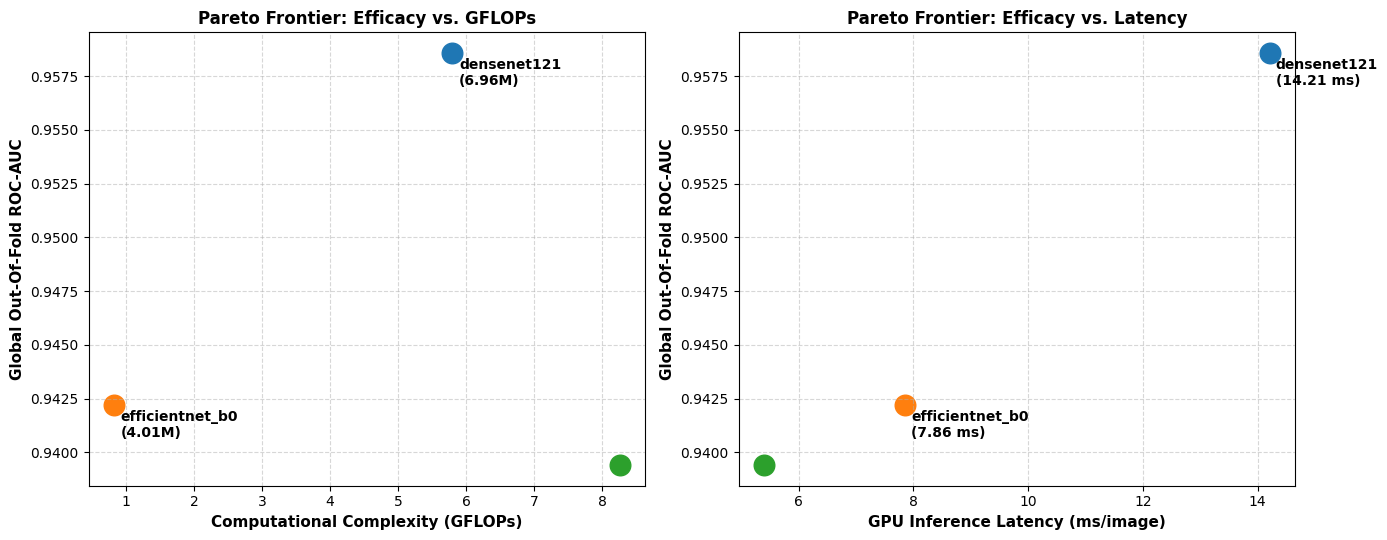


âœ… Benchmark Complete! Summary table and Pareto figures saved to /kaggle/working/


In [5]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score, accuracy_score
)
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info

# ============================================================
# 1. PRE-LOAD ALL 800 CXRs INTO RAM WITH CLAHE
# ============================================================
metadata_path = "/kaggle/working/tb_metadata.csv"
if not os.path.exists(metadata_path):
    raise FileNotFoundError("tb_metadata.csv not found. Execute the dataset verification cell first.")

df = pd.read_csv(metadata_path)
clahe_engine = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

print("âš¡ Pre-caching all 800 images into RAM with CLAHE...")
start_cache = time.time()
RAM_CACHE = {}
for _, row in df.iterrows():
    raw_img = cv2.imread(row["file_path"], cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        raise FileNotFoundError(f"Failed to read image at: {row['file_path']}")
    resized = cv2.resize(raw_img, (224, 224), interpolation=cv2.INTER_AREA)
    enhanced = clahe_engine.apply(resized)
    # Store as RGB uint8 array in RAM (~150 KB per image)
    RAM_CACHE[row["image_id"]] = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

print(f"âœ… Cached {len(RAM_CACHE)} images into RAM in {time.time() - start_cache:.2f}s! Data I/O bottleneck eliminated.\n")

# ============================================================
# 2. FAST IN-MEMORY DATASET WITH SPECIFIED AUGMENTATION
# ============================================================
class FastTBChestXRayDataset(Dataset):
    def __init__(self, df_subset, ram_cache, is_train=True):
        self.df = df_subset.reset_index(drop=True)
        self.ram_cache = ram_cache
        self.is_train = is_train
        
        # Training Augmentation: Rotation Â±10Â°, Flip 50%, Shear Â±5Â°
        if self.is_train:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.RandomRotation(degrees=10),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomAffine(degrees=0, shear=(-5, 5)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            # Validation: Deterministic normalization only
            self.transform = T.Compose([
                T.ToPILImage(),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_rgb = self.ram_cache[row["image_id"]]
        tensor = self.transform(img_rgb)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return tensor, label, row["image_id"]

# ============================================================
# 3. MODEL FACTORY (EXPLICIT PRETRAINED WEIGHT CONSTANTS)
# ============================================================
def build_model(arch_name):
    if arch_name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, 2)
    elif arch_name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, 2)
    elif arch_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)
    else:
        raise ValueError(f"Unsupported architecture: {arch_name}")
    return m

# ============================================================
# 4. HARDWARE EFFICIENCY PROFILER (STRICT ptflops)
# ============================================================
def profile_hardware_efficiency(arch_name, device, img_size=224, warmup=40, runs=150):
    model = build_model(arch_name).to(device)
    model.eval()
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    try:
        macs, _ = get_model_complexity_info(
            model, (3, img_size, img_size), 
            as_strings=False, print_per_layer_stat=False, verbose=False
        )
        gflops = (macs * 2.0) / 1e9  # 1 MAC = 2 FLOPs
    except Exception as e:
        raise RuntimeError(f"Strict FLOPs profiling failed for {arch_name}: {e}")
    
    dummy = torch.randn(1, 3, img_size, img_size, device=device)
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
            
        start = time.perf_counter()
        for _ in range(runs):
            _ = model(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()
        latency_ms = ((time.perf_counter() - start) / runs) * 1000.0

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
        
    return params, gflops, latency_ms

# ============================================================
# 5. METRIC ENGINE
# ============================================================
def compute_binary_metrics(y_true, y_probs, y_preds):
    auc = roc_auc_score(y_true, y_probs)
    tn, fp, fn, tp = confusion_matrix(y_true, y_preds).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_preds, zero_division=0)
    f1 = f1_score(y_true, y_preds, zero_division=0)
    acc = accuracy_score(y_true, y_preds)
    return {"AUC": auc, "Sensitivity": sens, "Specificity": spec, "Precision": prec, "F1": f1, "Accuracy": acc}

# ============================================================
# 6. EXECUTION PIPELINE (30 EPOCHS, PATIENCE 7, BATCH SIZE 32)
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

ARCHITECTURES = ["resnet50", "densenet121", "efficientnet_b0"]
MAX_EPOCHS = 30
PATIENCE = 7
BATCH_SIZE = 32

benchmark_summary = []
all_oof_dfs = {}

for arch in ARCHITECTURES:
    print(f"\n=======================================================")
    print(f"            BENCHMARKING: {arch.upper()}")
    print(f"=======================================================")
    
    params, gflops, latency = profile_hardware_efficiency(arch, device)
    print(f"Complexity: {params/1e6:.2f}M Params | {gflops:.2f} GFLOPs | {latency:.2f} ms/img")
    
    fold_metric_records = []
    oof_predictions = []
    checkpoint_sizes = []
    
    for fold in range(5):
        fold_start = time.time()
        train_sub = df[df["fold"] != fold]
        val_sub = df[df["fold"] == fold]
        
        train_loader = DataLoader(FastTBChestXRayDataset(train_sub, RAM_CACHE, is_train=True), 
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
        val_loader = DataLoader(FastTBChestXRayDataset(val_sub, RAM_CACHE, is_train=False), 
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
        
        model = build_model(arch).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
        
        best_val_auc = 0.0
        patience_counter = 0
        best_ckpt_path = f"/kaggle/working/{arch}_fold{fold}_best.pth"
        
        # 1. Training Loop with Early Stopping
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for imgs, labels, _ in train_loader:
                imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            scheduler.step()
            
            # Validation Pass
            model.eval()
            val_targets, val_probs = [], []
            with torch.no_grad():
                for imgs, labels, _ in val_loader:
                    imgs = imgs.to(device, non_blocking=True)
                    out = model(imgs)
                    p = torch.softmax(out, dim=1)[:, 1]
                    val_probs.extend(p.cpu().numpy())
                    val_targets.extend(labels.numpy())
            
            epoch_auc = roc_auc_score(val_targets, val_probs)
            
            if epoch_auc > best_val_auc + 1e-4:
                best_val_auc = epoch_auc
                patience_counter = 0
                torch.save(model.state_dict(), best_ckpt_path)
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    break
        
        # 2. Strict OOF Inference using best saved checkpoint
        model.load_state_dict(torch.load(best_ckpt_path))
        model.eval()
        
        fold_targets, fold_probs, fold_preds, fold_ids = [], [], [], []
        with torch.no_grad():
            for imgs, labels, img_ids in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                out = model(imgs)
                p = torch.softmax(out, dim=1)[:, 1]
                pr = torch.argmax(out, dim=1)
                fold_probs.extend(p.cpu().numpy())
                fold_preds.extend(pr.cpu().numpy())
                fold_targets.extend(labels.numpy())
                fold_ids.extend(img_ids)
                
        fold_m = compute_binary_metrics(np.array(fold_targets), np.array(fold_probs), np.array(fold_preds))
        fold_metric_records.append(fold_m)
        
        for i in range(len(fold_ids)):
            oof_predictions.append({
                "image_id": fold_ids[i],
                "fold": fold,
                "label": fold_targets[i],
                "prob_tb": fold_probs[i],
                "pred_label": fold_preds[i]
            })
            
        ckpt_mb = os.path.getsize(best_ckpt_path) / (1024 * 1024)
        checkpoint_sizes.append(ckpt_mb)
        
        fold_elapsed = time.time() - fold_start
        print(f"Fold {fold+1}/5 (Stopped ep {epoch:2d} | {fold_elapsed:.1f}s) | OOF AUC: {fold_m['AUC']:.4f} | Sens: {fold_m['Sensitivity']:.4f} | Spec: {fold_m['Specificity']:.4f} | F1: {fold_m['F1']:.4f}")
        
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    
    # 3. Overall OOF Aggregation
    oof_df = pd.DataFrame(oof_predictions)
    oof_df.to_csv(f"/kaggle/working/oof_predictions_{arch}.csv", index=False)
    all_oof_dfs[arch] = oof_df
    
    overall_oof = compute_binary_metrics(oof_df["label"].values, oof_df["prob_tb"].values, oof_df["pred_label"].values)
    
    auc_l = [f["AUC"] for f in fold_metric_records]
    sens_l = [f["Sensitivity"] for f in fold_metric_records]
    spec_l = [f["Specificity"] for f in fold_metric_records]
    prec_l = [f["Precision"] for f in fold_metric_records]
    f1_l = [f["F1"] for f in fold_metric_records]
    acc_l = [f["Accuracy"] for f in fold_metric_records]
    
    benchmark_summary.append({
        "Architecture": arch,
        "Params (M)": round(params / 1e6, 2),
        "GFLOPs": round(gflops, 2),
        "Disk (MB)": round(np.mean(checkpoint_sizes), 1),
        "Latency (ms)": round(latency, 2),
        "OOF ROC-AUC (Global)": round(overall_oof["AUC"], 4),
        "ROC-AUC (Mean Â± SD)": f"{np.mean(auc_l):.4f} Â± {np.std(auc_l):.4f}",
        "Sensitivity (Mean Â± SD)": f"{np.mean(sens_l):.4f} Â± {np.std(sens_l):.4f}",
        "Specificity (Mean Â± SD)": f"{np.mean(spec_l):.4f} Â± {np.std(spec_l):.4f}",
        "Precision (Mean Â± SD)": f"{np.mean(prec_l):.4f} Â± {np.std(prec_l):.4f}",
        "F1-Score (Mean Â± SD)": f"{np.mean(f1_l):.4f} Â± {np.std(f1_l):.4f}",
        "Accuracy (Mean Â± SD)": f"{np.mean(acc_l):.4f} Â± {np.std(acc_l):.4f}",
        "_raw_auc": overall_oof["AUC"],
        "_raw_gflops": gflops,
        "_raw_latency": latency
    })

# ============================================================
# 7. GENERATE FINAL TABLE 1 & PUBLICATION CHARTS
# ============================================================
summary_df = pd.DataFrame(benchmark_summary).sort_values(by="_raw_auc", ascending=False).reset_index(drop=True)
summary_df.to_csv("/kaggle/working/paper1_rigorous_benchmark.csv", index=False)

print("\n" + "="*80)
print("             TABLE 1: COMPREHENSIVE PAPER 1 BENCHMARK SUMMARY")
print("="*80)
display_cols = ["Architecture", "Params (M)", "GFLOPs", "Disk (MB)", "Latency (ms)", 
                "OOF ROC-AUC (Global)", "ROC-AUC (Mean Â± SD)", "Sensitivity (Mean Â± SD)", "Specificity (Mean Â± SD)", "F1-Score (Mean Â± SD)"]
print(summary_df[display_cols].to_string(index=False))

top_model = summary_df.iloc[0]
print("\n" + "="*80)
print(f"ðŸ† EMPIRICAL WINNER (PAPER 1): {top_model['Architecture'].upper()}")
print(f"   Global OOF ROC-AUC: {top_model['OOF ROC-AUC (Global)']} | 5-Fold Mean: {top_model['ROC-AUC (Mean Â± SD)']}")
print("="*80)

# Dual Pareto Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for _, row in summary_df.iterrows():
    ax1.scatter(row["_raw_gflops"], row["_raw_auc"], s=220, label=row["Architecture"])
    ax1.annotate(f"{row['Architecture']}\n({row['Params (M)']}M)", 
                 (row["_raw_gflops"] + 0.1, row["_raw_auc"] - 0.0015),
                 fontsize=10, weight='semibold')

ax1.set_xlabel("Computational Complexity (GFLOPs)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Global Out-Of-Fold ROC-AUC", fontsize=11, fontweight='bold')
ax1.set_title("Pareto Frontier: Efficacy vs. GFLOPs", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.5)

for _, row in summary_df.iterrows():
    ax2.scatter(row["_raw_latency"], row["_raw_auc"], s=220, label=row["Architecture"])
    ax2.annotate(f"{row['Architecture']}\n({row['Latency (ms)']} ms)", 
                 (row["_raw_latency"] + 0.1, row["_raw_auc"] - 0.0015),
                 fontsize=10, weight='semibold')

ax2.set_xlabel("GPU Inference Latency (ms/image)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Global Out-Of-Fold ROC-AUC", fontsize=11, fontweight='bold')
ax2.set_title("Pareto Frontier: Efficacy vs. Latency", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/kaggle/working/pareto_frontier_paper1.png", dpi=300)
plt.show()
print("\nâœ… Benchmark Complete! Summary table and Pareto figures saved to /kaggle/working/")

In [6]:
import os

print("================ AVAILABLE PAPER 1 ARTIFACTS ================")
for f in sorted(os.listdir("/kaggle/working")):
    if any(x in f.lower() for x in ["oof", "benchmark", "metadata", "pareto", ".pth", ".tex", ".csv", ".png"]):
        path = os.path.join("/kaggle/working", f)
        if os.path.isfile(path):
            size_mb = os.path.getsize(path) / (1024**2)
            print(f"{f:55s} {size_mb:6.2f} MB")

================ AVAILABLE PAPER 1 ARTIFACTS ================
densenet121_fold0_best.pth                               27.12 MB
densenet121_fold1_best.pth                               27.12 MB
densenet121_fold2_best.pth                               27.12 MB
densenet121_fold3_best.pth                               27.12 MB
densenet121_fold4_best.pth                               27.12 MB
efficientnet_b0_fold0_best.pth                           15.59 MB
efficientnet_b0_fold1_best.pth                           15.59 MB
efficientnet_b0_fold2_best.pth                           15.59 MB
efficientnet_b0_fold3_best.pth                           15.59 MB
efficientnet_b0_fold4_best.pth                           15.59 MB
oof_predictions_densenet121.csv                           0.03 MB
oof_predictions_efficientnet_b0.csv                       0.03 MB
oof_predictions_resnet50.csv                              0.03 MB
paper1_rigorous_benchmark.csv                             0.00 MB
pareto_frontie

In [7]:
import os
import glob
import pandas as pd

print("================ OOF FILE SCHEMA AUDIT ================")

oof_files = glob.glob("/kaggle/working/oof_predictions_*.csv")

for path in sorted(oof_files):
    df = pd.read_csv(path)

    print(f"\nFile: {os.path.basename(path)}")
    print(f"Total Rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")
    print("Sample Data:")
    print(df.head(2))

================ OOF FILE SCHEMA AUDIT ================

File: oof_predictions_densenet121.csv
Total Rows: 800
Columns: ['image_id', 'fold', 'label', 'prob_tb', 'pred_label']
Sample Data:
            image_id  fold  label   prob_tb  pred_label
0  CHNCXR_0001_0.png     0      0  0.000634           0
1  CHNCXR_0004_0.png     0      0  0.000400           0

File: oof_predictions_efficientnet_b0.csv
Total Rows: 800
Columns: ['image_id', 'fold', 'label', 'prob_tb', 'pred_label']
Sample Data:
            image_id  fold  label   prob_tb  pred_label
0  CHNCXR_0001_0.png     0      0  0.034220           0
1  CHNCXR_0004_0.png     0      0  0.042216           0

File: oof_predictions_resnet50.csv
Total Rows: 800
Columns: ['image_id', 'fold', 'label', 'prob_tb', 'pred_label']
Sample Data:
            image_id  fold  label   prob_tb  pred_label
0  CHNCXR_0001_0.png     0      0  0.581475           1
1  CHNCXR_0004_0.png     0      0  0.060718           0


In [8]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score, accuracy_score
)

print("=" * 70)
print("           PAPER 1 FORMAL OUT-OF-FOLD (OOF) AUDIT PIPELINE")
print("=" * 70)

# ---------------------------------------------------------
# 1. Load Metadata & Reference Data
# ---------------------------------------------------------
meta_path = "/kaggle/working/tb_metadata.csv"
if not os.path.exists(meta_path):
    raise FileNotFoundError("tb_metadata.csv not found in /kaggle/working.")

meta_df = pd.read_csv(meta_path)
print(f"Loaded tb_metadata.csv: {len(meta_df)} rows")

meta_map = dict(zip(meta_df["image_id"], meta_df["source_dataset"]))
meta_labels = dict(zip(meta_df["image_id"], meta_df["label"]))
meta_folds = dict(zip(meta_df["image_id"], meta_df["fold"]))

models = ["resnet50", "densenet121", "efficientnet_b0"]
oof = {}

# ---------------------------------------------------------
# 2. Data Integrity & Consistency Verification
# ---------------------------------------------------------
print("\n--- 1. DATA INTEGRITY CHECK ---")
for model in models:
    file_path = f"/kaggle/working/oof_predictions_{model}.csv"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing OOF file: {file_path}")
    
    df = pd.read_csv(file_path)
    
    # Assert row count
    assert len(df) == 800, f"{model} has {len(df)} rows, expected 800."
    
    # Assert columns
    required_cols = {"image_id", "fold", "label", "prob_tb", "pred_label"}
    assert required_cols.issubset(df.columns), f"{model} missing required columns."
    
    # Assert image_id alignment and label/fold matching
    for _, row in df.iterrows():
        img_id = row["image_id"]
        assert img_id in meta_map, f"Unknown image_id {img_id} in {model}"
        assert row["label"] == meta_labels[img_id], f"Label mismatch for {img_id} in {model}"
        assert row["fold"] == meta_folds[img_id], f"Fold mismatch for {img_id} in {model}"
        assert 0.0 <= row["prob_tb"] <= 1.0, f"Probability out of bounds for {img_id} in {model}"
    
    df["source_dataset"] = df["image_id"].map(meta_map)
    oof[model] = df
    print(f"âœ… {model:15s}: 800 predictions verified (Labels, Folds, Probabilities intact)")

# ---------------------------------------------------------
# 3. Metric Computation Engine
# ---------------------------------------------------------
def compute_all_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {
        "ROC-AUC": auc,
        "Sensitivity": sens,
        "Specificity": spec,
        "Precision": prec,
        "F1-Score": f1,
        "Accuracy": acc,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }

# ---------------------------------------------------------
# 4. Global Pooled OOF Performance
# ---------------------------------------------------------
global_records = []
for model in models:
    df = oof[model]
    m = compute_all_metrics(df["label"], df["prob_tb"], df["pred_label"])
    global_records.append({
        "Architecture": model,
        "Global OOF ROC-AUC": round(m["ROC-AUC"], 4),
        "Sensitivity": round(m["Sensitivity"], 4),
        "Specificity": round(m["Specificity"], 4),
        "Precision": round(m["Precision"], 4),
        "F1-Score": round(m["F1-Score"], 4),
        "Accuracy": round(m["Accuracy"], 4),
        "Confusion Matrix (TP/FP/TN/FN)": f"{m['TP']}/{m['FP']}/{m['TN']}/{m['FN']}"
    })

global_df = pd.DataFrame(global_records).sort_values(by="Global OOF ROC-AUC", ascending=False)
print("\n" + "=" * 70)
print("             GLOBAL OUT-OF-FOLD PERFORMANCE (N=800)")
print("=" * 70)
print(global_df.to_string(index=False))

# ---------------------------------------------------------
# 5. Cohort-Specific Subgroup Breakdown
# ---------------------------------------------------------
cohort_records = []
for model in models:
    df = oof[model]
    
    sz_df = df[df["source_dataset"] == "Shenzhen"]
    sz_m = compute_all_metrics(sz_df["label"], sz_df["prob_tb"], sz_df["pred_label"])
    
    mc_df = df[df["source_dataset"] == "Montgomery"]
    mc_m = compute_all_metrics(mc_df["label"], mc_df["prob_tb"], mc_df["pred_label"])
    
    cohort_records.append({
        "Architecture": model,
        "Shenzhen AUC (N=662)": round(sz_m["ROC-AUC"], 4),
        "Shenzhen Sens": round(sz_m["Sensitivity"], 4),
        "Shenzhen Spec": round(sz_m["Specificity"], 4),
        "Montgomery AUC (N=138)": round(mc_m["ROC-AUC"], 4),
        "Montgomery Sens": round(mc_m["Sensitivity"], 4),
        "Montgomery Spec": round(mc_m["Specificity"], 4)
    })

cohort_df = pd.DataFrame(cohort_records)
print("\n" + "=" * 70)
print("        COHORT-SPECIFIC OOF PERFORMANCE (Shenzhen vs Montgomery)")
print("=" * 70)
print(cohort_df.to_string(index=False))

# ---------------------------------------------------------
# 6. Fold-Level Metrics & Benchmark Reproduction
# ---------------------------------------------------------
fold_auc_data = {"Fold": [f"Fold {i+1}" for i in range(5)]}
fold_metrics = {m: [] for m in models}

for model in models:
    df = oof[model]
    for f in range(5):
        sub = df[df["fold"] == f]
        m = compute_all_metrics(sub["label"], sub["prob_tb"], sub["pred_label"])
        fold_metrics[model].append(m)
    fold_auc_data[model] = [round(m["ROC-AUC"], 4) for m in fold_metrics[model]]

fold_df = pd.DataFrame(fold_auc_data)
print("\n" + "=" * 70)
print("             FIVE-FOLD VALIDATION ROC-AUC AUDIT")
print("=" * 70)
print(fold_df.to_string(index=False))

summary_records = []
for model in models:
    aucs = [m["ROC-AUC"] for m in fold_metrics[model]]
    sens = [m["Sensitivity"] for m in fold_metrics[model]]
    specs = [m["Specificity"] for m in fold_metrics[model]]
    f1s = [m["F1-Score"] for m in fold_metrics[model]]
    
    summary_records.append({
        "Architecture": model,
        "ROC-AUC (Mean Â± SD)": f"{np.mean(aucs):.4f} Â± {np.std(aucs):.4f}",
        "Sensitivity (Mean Â± SD)": f"{np.mean(sens):.4f} Â± {np.std(sens):.4f}",
        "Specificity (Mean Â± SD)": f"{np.mean(specs):.4f} Â± {np.std(specs):.4f}",
        "F1-Score (Mean Â± SD)": f"{np.mean(f1s):.4f} Â± {np.std(f1s):.4f}"
    })

summary = pd.DataFrame(summary_records)
print("\n" + "=" * 70)
print("             FIVE-FOLD AGGREGATED SUMMARY (Mean Â± SD)")
print("=" * 70)
print(summary.to_string(index=False))

# ---------------------------------------------------------
# 7. Statistical Paired Comparison (DenseNet121 vs EfficientNet-B0)
# ---------------------------------------------------------
dense = np.array([m["ROC-AUC"] for m in fold_metrics["densenet121"]])
eff = np.array([m["ROC-AUC"] for m in fold_metrics["efficientnet_b0"]])

mean_difference = dense.mean() - eff.mean()
t_stat, p_value = stats.ttest_rel(dense, eff)

print("\n" + "=" * 70)
print("      PAIRED STATISTICAL COMPARISON: DenseNet121 vs EfficientNet-B0")
print("=" * 70)
print(f"DenseNet mean AUC:      {dense.mean():.4f}")
print(f"EfficientNet mean AUC:  {eff.mean():.4f}")
print(f"Mean paired difference: {mean_difference:+.4f}")
print(f"Paired t-statistic:     {t_stat:.4f}")
print(f"Paired t-test p-value:  {p_value:.4f}")

if p_value < 0.05:
    print("Interpretation: statistically significant difference detected at alpha=0.05.")
else:
    print("Interpretation: no statistically significant difference detected at alpha=0.05.")

print("\nIMPORTANT: A p-value >= 0.05 does NOT prove the models are statistically equivalent.")

# ---------------------------------------------------------
# 8. Save Audited Files & Summary Tables
# ---------------------------------------------------------
for model in models:
    output = f"/kaggle/working/oof_predictions_{model}_audited.csv"
    oof[model].to_csv(output, index=False)

global_df.to_csv("/kaggle/working/paper1_global_oof_audit.csv", index=False)
cohort_df.to_csv("/kaggle/working/paper1_cohort_oof_audit.csv", index=False)
fold_df.to_csv("/kaggle/working/paper1_fold_auc_audit.csv", index=False)
summary.to_csv("/kaggle/working/paper1_fold_summary_audit.csv", index=False)

print("\n" + "=" * 70)
print("âœ… PAPER 1 FORMAL OOF AUDIT COMPLETED")
print("=" * 70)
print("\nSaved files to /kaggle/working/:")
print(" - paper1_global_oof_audit.csv")
print(" - paper1_cohort_oof_audit.csv")
print(" - paper1_fold_auc_audit.csv")
print(" - paper1_fold_summary_audit.csv")
print(" - oof_predictions_resnet50_audited.csv")
print(" - oof_predictions_densenet121_audited.csv")
print(" - oof_predictions_efficientnet_b0_audited.csv")

           PAPER 1 FORMAL OUT-OF-FOLD (OOF) AUDIT PIPELINE
Loaded tb_metadata.csv: 800 rows

--- 1. DATA INTEGRITY CHECK ---
âœ… resnet50       : 800 predictions verified (Labels, Folds, Probabilities intact)
âœ… densenet121    : 800 predictions verified (Labels, Folds, Probabilities intact)
âœ… efficientnet_b0: 800 predictions verified (Labels, Folds, Probabilities intact)

             GLOBAL OUT-OF-FOLD PERFORMANCE (N=800)
   Architecture  Global OOF ROC-AUC  Sensitivity  Specificity  Precision  F1-Score  Accuracy Confusion Matrix (TP/FP/TN/FN)
    densenet121              0.9586       0.8731       0.9261     0.9198    0.8958     0.900                  344/30/376/50
efficientnet_b0              0.9422       0.8756       0.9039     0.8984    0.8869     0.890                  345/39/367/49
       resnet50              0.9394       0.9036       0.8276     0.8357    0.8683     0.865                  356/70/336/38

        COHORT-SPECIFIC OOF PERFORMANCE (Shenzhen vs Montgomery)
   Archi